In [39]:
# function tranformation, is used to convert the non normal distribution data into normal distribution dataseugh, 
# or when the data is 
# we can use any kind of function or when the dataset is too huge that even scaling doesnt help enough, 
# or when the data is( cm,m,kelvin ,km ) changing patterns then we cana use function transformation

In [40]:
# for the function transformation we have to remove outliers then we can continue

In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
dataset=pd.read_csv(r"C:\Users\dell\Documents\excells\data1.csv")
dataset.head(3)

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000,S,Biggin,3/12/2016,2.5,3067,...,1,1.0,202,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019
1,Abbotsford,25 Bloomburg St,2,h,1035000,S,Biggin,4/2/2016,2.5,3067,...,1,0.0,156,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019
2,Abbotsford,5 Charles St,3,h,1465000,SP,Biggin,4/3/2017,2.5,3067,...,2,0.0,134,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019


In [42]:
dataset.isnull().sum()

Suburb              0
Address             0
Rooms               0
Type                0
Price               0
Method              0
SellerG             0
Date                0
Distance            0
Postcode            0
Bedroom2            0
Bathroom            0
Car                62
Landsize            0
BuildingArea     6450
YearBuilt        5375
CouncilArea      1369
Lattitude           0
Longtitude          0
Regionname          0
Propertycount       0
dtype: int64

In [43]:
dataset.shape

(13580, 21)

C:\Users\dell\AppData\Local\Temp\ipykernel_35860\455196228.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset["Landsize"])


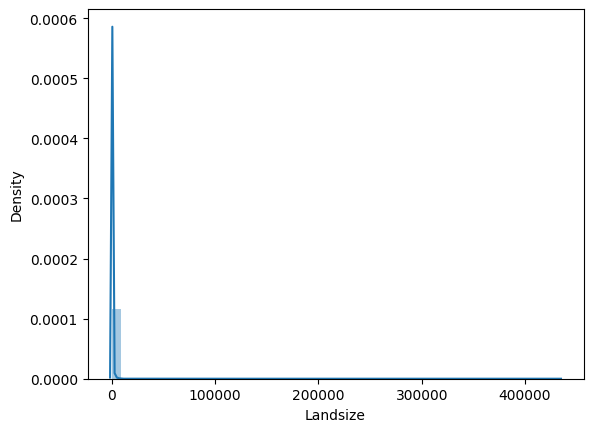

In [44]:
sns.distplot(dataset["Landsize"])
plt.show()


In [45]:
# first we have to remove the outliers as seen in the graphs using IQR method
Q1=dataset["Landsize"].quantile(0.25)
Q3=dataset["Landsize"].quantile(0.75)

In [46]:
IQR=Q3-Q1
min=Q1-(1.5*IQR)
max=Q3+(1.5*IQR)
max,min

(np.float64(1362.0), np.float64(-534.0))

In [47]:
clean_data=dataset[dataset["Landsize"]<=max]

till here we have removed the outliers from the data 

In [48]:
clean_data.shape

(13212, 21)

C:\Users\dell\AppData\Local\Temp\ipykernel_35860\2177151892.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(clean_data["Landsize"])


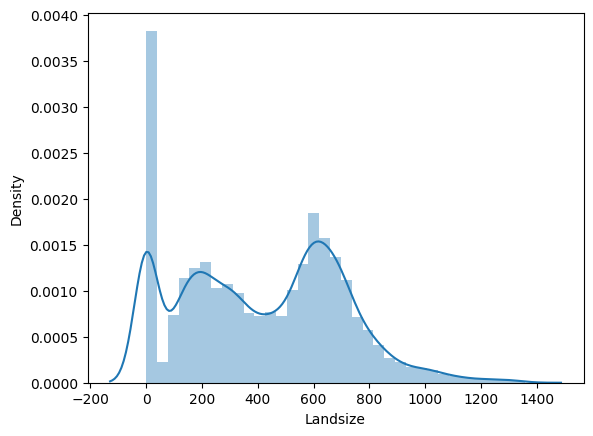

In [49]:
# checking out the data after removing maximum outliers
sns.distplot(clean_data["Landsize"])
plt.show()

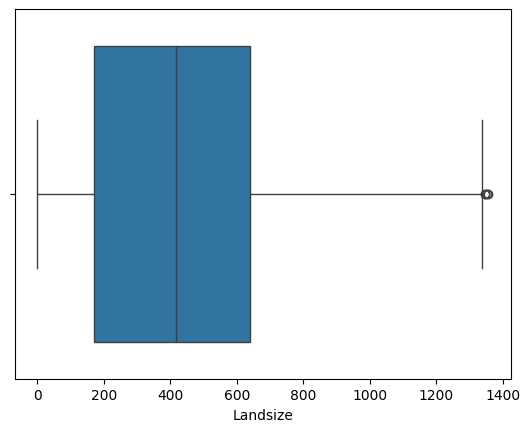

In [50]:
sns.boxplot(x="Landsize",data=clean_data)
plt.show()

In [51]:
# from heree we gonn find the function transformation of the datasets of removed outliers, using skleran
# for this we gonna use log funcition for function transformation and applying numpy
from sklearn.preprocessing import FunctionTransformer
FT=FunctionTransformer(func=np.log1p) #we can use (log base 10) or (log base e) but using thosse when 0 
# occurs these doesnt work instead we use (log1p=(p-1)) as it can work efficently when its has 0 and subtract (p-1) excluding infinty


In [52]:
FT.fit(clean_data["Landsize"])

,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<ufunc 'log1p'>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to pass to func... versionadded:: 0.18",None
,"inv_kw_args inv_kw_args: dict, default=NoneDictionary of additional keyword arguments to pass to inverse_func... versionadded:: 0.18",None


In [53]:
clean_data["Landsize_FT"]=FT.transform(clean_data[["Landsize"]])

C:\Users\dell\AppData\Local\Temp\ipykernel_35860\1662923554.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_data["Landsize_FT"]=FT.transform(clean_data[["Landsize"]])


C:\Users\dell\AppData\Local\Temp\ipykernel_35860\4021568793.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(clean_data["Landsize"])
C:\Users\dell\AppData\Local\Temp\ipykernel_35860\4021568793.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(clean_data["Landsize_FT"])


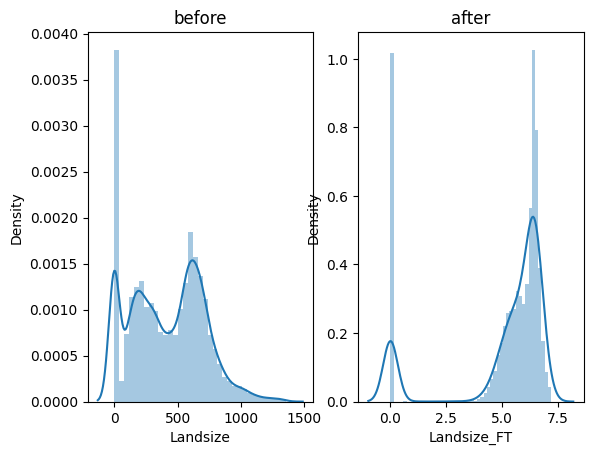

In [54]:
plt.Figure(figsize=(10,4))
plt.subplot(1,2,1)   #1 row, 2 column, 1 place
plt.title("before")
sns.distplot(clean_data["Landsize"])

plt.subplot(1,2,2) 

sns.distplot(clean_data["Landsize_FT"]) 
plt.title("after")
plt.show()


In [55]:
# lets use x^2 insteaad log1p
FT1=FunctionTransformer(func=lambda x:x**2) #we have to use lamda 
FT1.fit(clean_data["Landsize"])
clean_data["Landsize_ft1"]=FT1.transform(clean_data[["Landsize"]])

C:\Users\dell\AppData\Local\Temp\ipykernel_35860\3782575527.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_data["Landsize_ft1"]=FT1.transform(clean_data[["Landsize"]])


C:\Users\dell\AppData\Local\Temp\ipykernel_35860\2538462734.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(clean_data["Landsize"])
C:\Users\dell\AppData\Local\Temp\ipykernel_35860\2538462734.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(clean_data["Landsize_ft1"])


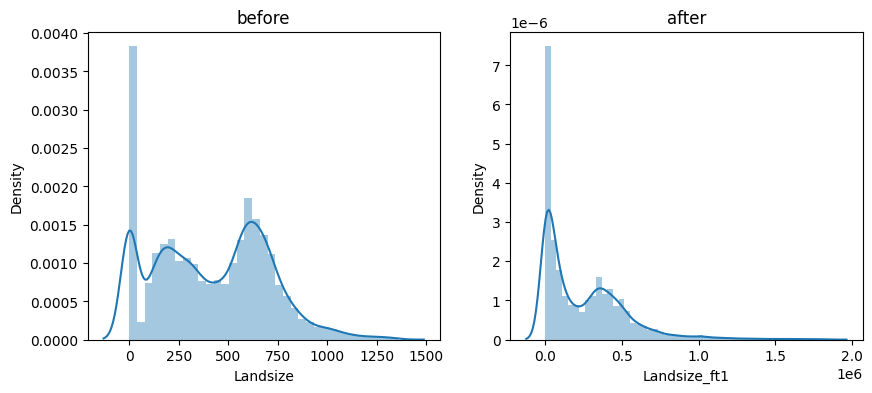

In [56]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title("before")
sns.distplot(clean_data["Landsize"])

plt.subplot(1,2,2)
plt.title("after")
sns.distplot(clean_data["Landsize_ft1"])
plt.show()

In [57]:
clean_data.head(4)


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount,Landsize_FT,Landsize_ft1
0,Abbotsford,85 Turner St,2,h,1480000,S,Biggin,3/12/2016,2.5,3067,...,202,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019,5.313206,40804
1,Abbotsford,25 Bloomburg St,2,h,1035000,S,Biggin,4/2/2016,2.5,3067,...,156,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019,5.056246,24336
2,Abbotsford,5 Charles St,3,h,1465000,SP,Biggin,4/3/2017,2.5,3067,...,134,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019,4.905275,17956
3,Abbotsford,40 Federation La,3,h,850000,PI,Biggin,4/3/2017,2.5,3067,...,94,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019,4.553877,8836
